# Define your own model structure

In this notebook we look at how to define your _own_ hydrologic model structure.
If none of the included structures fit the system you are studying, you can
describe your own as a list of "layers", where each layer is a list of zones.
We build a five-zone model with two lateral columns (a hilly, upland **hillslope**
and a wetter, valley-bottom **riparian** zone) and a single shared groundwater
bucket at the bottom:

- Layer 1: `snow_hs`, `snow_rp` (two snow zones)
- Layer 2: `surface_hs`, `surface_rp` (two surface zones)
- Layer 3: `ground` (one groundwater zone)

The steps are:

1. Load the downloaded input hydrology data
2. Construct the forcing data object(s)
3. Overview the built-in model structures
4. Define our new model structure
5. Run the simulation with our new model
6. Observe our new model results (focus on the hillslope and riparian zones)

As with the previous script, this is a Jupytext-style percent script: code
cells are delimited by `# %%` and text cells by `# %% [markdown]`.

In [1]:
import os

import matplotlib.pyplot as plt
import pandas as pd
import potions as pt
from matplotlib.axes import Axes
from matplotlib.figure import Figure
from pandas import DataFrame, Series

data_dir: str = "../data"
forcing_path: str = os.path.join(data_dir, "model_inputs", "forcing.csv")
measured_path: str = os.path.join(data_dir, "model_inputs", "measured_data.csv")

## 1. Load the input hydrology data

This is the same data used in `2_Run_Hydrologic_Model.py`: daily forcing
(`ppt`, `temp`, `pet`) and the observed streamflow (`q_mmd`). We read both into
DataFrames with a parsed datetime index.

In [2]:
forcing_df: DataFrame = pd.read_csv(forcing_path, index_col=0, parse_dates=True)
measured_df: DataFrame = pd.read_csv(measured_path, index_col=0, parse_dates=True)

print(
    f"Forcing spans {forcing_df.index[0].date()} to {forcing_df.index[-1].date()} ({len(forcing_df)} days)"
)
print(
    f"Measured streamflow spans {measured_df.index[0].date()} to {measured_df.index[-1].date()} ({len(measured_df)} days)"
)

forcing_df.head()

Forcing spans 2008-10-01 to 2015-09-30 (2554 days)
Measured streamflow spans 2009-10-01 to 2015-09-30 (2191 days)


,ppt,temp,pet
time,,,
2008-10-01,3.5,10.500000,2.4
2008-10-02,2.2,5.500000,2.0
2008-10-03,1.6,4.899994,2.2
2008-10-04,0.0,5.100006,2.4
2008-10-05,0.0,7.149994,1.8


## 2. Construct the input forcing data object

The new model has **two surface zones** (the hillslope and the riparian zone),
so it expects **two** `pt.ForcingData` objects - one per column. For this
tutorial we use the same daily drivers for both columns (a single weather
record); a real application could apply lapse-rate scaling to give each column
its own series. The observed streamflow is still a single series.

In [3]:
hs_forcing: pt.ForcingData = pt.ForcingData(
    precip=forcing_df["ppt"], temp=forcing_df["temp"], pet=forcing_df["pet"]
)
rp_forcing: pt.ForcingData = pt.ForcingData(
    precip=forcing_df["ppt"], temp=forcing_df["temp"], pet=forcing_df["pet"]
)

# A list of ForcingData objects, one per surface column, ordered [hillslope, riparian].
forcing_list: list[pt.ForcingData] = [hs_forcing, rp_forcing]

meas_streamflow: Series = measured_df["q_mmd"]
print(f"Number of surface forcing series: {len(forcing_list)}")
print(f"Number of measured streamflow values: {len(meas_streamflow)}")

Number of surface forcing series: 2
Number of measured streamflow values: 2191


## 3. Overview of the built-in model structures

`potions` bundles several ready-made `Model` subclasses. Each is just a list of
layers, where a layer is a list of zones ordered from the top of the column to
the bottom. A couple of them are shown below; note that they are read-only
*templates* - to use your own layout you subclass `pt.Model` yourself.

- `HbvModel` - a single column: snow, surface, shallow, deep.
- `HbvLateralModel` - two parallel columns (e.g. hillslope + riparian), each
  with snow, surface, shallow, deep (8 zones total).

In [4]:
def layer_summary(structure: list[list[pt.HydrologicZone]]) -> list[str]:
    """Return a short, human-readable description of each layer in a structure."""
    return [", ".join(zone.__class__.__name__ for zone in layer) for layer in structure]


print("Built-in single-column structure (HbvModel):")
for line in layer_summary(pt.HbvModel.structure):
    print(f"  - {line}")
print()
print("Built-in two-column structure (HbvLateralModel):")
for line in layer_summary(pt.HbvLateralModel.structure):
    print(f"  - {line}")

Built-in single-column structure (HbvModel):
  - SnowZone
  - SurfaceZone
  - GroundZone
  - GroundZoneB

Built-in two-column structure (HbvLateralModel):
  - SnowZone, SnowZone
  - SurfaceZone, SurfaceZone
  - GroundZone, GroundZone
  - GroundZoneB, GroundZoneB


## 4. Define our new model structure

We subclass `pt.Model` and assign a `structure` class attribute: a list of
layers, each a list of zones. This example is a *tapered* column:

- **Snow layer** - two zones, `snow_hs` (hillslope) and `snow_rp` (riparian)
- **Surface layer** - two zones, `surface_hs` and `surface_rp`
- **Groundwater layer** - a single aggregated `ground` zone

The connection rules are: zones flow vertically to the zone directly below
them when both layers have the same number of zones, and to a lone
aggregated zone below when the lower layer has a single one; within a layer,
zones flow laterally toward the last zone of that layer, and the last zone of
each layer discharges to the river. Here both surface columns therefore feed
down into the one `ground` zone, and the shared groundwater storage is what
forms the outlet streamflow.

We also tell the model the fraction of the catchment each column represents
with `scales` (they must sum to 1). The hillslope is the larger, drier part.

In [5]:
class MyCustomModel(pt.Model):
    """A five-zone model: two lateral columns (hillslope, riparian) over one
    shared groundwater reservoir."""

    structure: list[list[pt.HydrologicZone]] = [
        [pt.SnowZone(name="snow_hs"), pt.SnowZone(name="snow_rp")],
        [pt.SurfaceZone(name="surface_hs"), pt.SurfaceZone(name="surface_rp")],
        [pt.SubsurfaceZoneB(name="ground")],
    ]

    @property
    def snow_hs(self) -> pt.SnowZone:
        return self.hydro_zones["snow_hs"]  # type: ignore

    @property
    def snow_rp(self) -> pt.SnowZone:
        return self.hydro_zones["snow_rp"]  # type: ignore

    @property
    def surface_hs(self) -> pt.SurfaceZone:
        return self.hydro_zones["surface_hs"]  # type: ignore

    @property
    def surface_rp(self) -> pt.SurfaceZone:
        return self.hydro_zones["surface_rp"]  # type: ignore

    @property
    def ground(self) -> pt.SubsurfaceZoneB:
        return self.hydro_zones["ground"]  # type: ignore


# Fractional catchment area of each surface column (must sum to 1).
hillslope_scale: float = 0.7
riparian_scale: float = 0.3
scales: list[float] = [hillslope_scale, riparian_scale]

# Create the model, injecting our custom zones and column scales.
model: MyCustomModel = MyCustomModel(scales=scales)
model.surface_hs.fc = 200.0
model.surface_hs.thr = 20.0
model.surface_rp.fc = 300.0
model.surface_rp.thr = 30.0

print("Zones in the model (top to bottom):")
for zone_name in model.get_zone_names():
    print(f"  - {zone_name}: {model[zone_name].__class__.__name__}")
print(f"Surface columns: {model.num_surface_zones}, scales: {model.scales}")

# Complete parameterisation, keyed as '<zone>.<parameter>' (plus column scales).
model.to_dict()

Zones in the model (top to bottom):
  - snow_hs: SnowZone
  - snow_rp: SnowZone
  - surface_hs: SurfaceZone
  - surface_rp: SurfaceZone
  - ground: GroundZoneB
Surface columns: 2, scales: [0.7, 0.3]


{'snow_hs.tt': np.float64(0.0),
 'snow_hs.fmax': np.float64(1.0),
 'snow_rp.tt': np.float64(0.0),
 'snow_rp.fmax': np.float64(1.0),
 'surface_hs.fc': np.float64(200.0),
 'surface_hs.lp': np.float64(0.5),
 'surface_hs.beta': np.float64(1.0),
 'surface_hs.k0': np.float64(0.1),
 'surface_hs.thr': np.float64(20.0),
 'surface_rp.fc': np.float64(300.0),
 'surface_rp.lp': np.float64(0.5),
 'surface_rp.beta': np.float64(1.0),
 'surface_rp.k0': np.float64(0.1),
 'surface_rp.thr': np.float64(30.0),
 'ground.k': np.float64(0.01),
 'ground.alpha': np.float64(1.0),
 'proportion.1': np.float64(0.7)}

## 5. Run the model

We step the model forward in time, passing the list of two forcing series
(one per column) and the observed streamflow so the run also reports the
performance metrics.

In [6]:
hydro_res: pt.HydroModelResults = model.run_hydro_model(
    forc=forcing_list,
    meas_streamflow=meas_streamflow,
)

print("Simulation complete.")

Simulation complete.


## 6. View the model outputs

As before, `run_hydro_model` returns a `pt.HydroModelResults`. Its
`simulation` DataFrame has one block of eight columns per zone (storage plus
the inflow, evaporation, lateral, vertical, and external fluxes), plus
`streamflow_sim` and `meas_streamflow`. Because there are five zones,
there are 5 * 8 + 2 = 42 columns.

In [7]:
print("Performance metrics:")
print(hydro_res.objective_functions)
print()

simulation_df: DataFrame = hydro_res.simulation
print(f"Simulation output shape: {simulation_df.shape}")
print()
simulation_df.head()

Performance metrics:
kge             0.058097
log_kge        -0.236967
nse             0.081767
log_nse        -0.253272
bias            0.377064
spearman_rho    0.590123
r_squared       0.130691
dtype: float64

Simulation output shape: (2554, 45)



,s_snow_hs,q_forc_snow_hs,q_vap_snow_hs,q_lat_snow_hs,q_vert_snow_hs,q_in_snow_hs,q_lat_ext_snow_hs,q_vert_ext_snow_hs,s_snow_rp,q_forc_snow_rp,...,q_lat_ground,q_vert_ground,q_in_ground,q_lat_ext_ground,q_vert_ext_ground,streamflow_sim,meas_streamflow_mmd,prop_q_snow_rp,prop_q_surface_rp,prop_q_ground
time,,,,,,,,,,,,,,,,,,,,,
2008-10-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.45,0.0,0.0,...,0.103618,0.0,0.465388,0.103618,0.0,0.103618,NaN,0.0,0.0,1.0
2008-10-02,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.54,0.0,0.0,...,0.105784,0.0,0.322430,0.105784,0.0,0.105784,NaN,0.0,0.0,1.0
2008-10-03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.12,0.0,0.0,...,0.107240,0.0,0.252784,0.107240,0.0,0.107240,NaN,0.0,0.0,1.0
2008-10-04,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,...,0.106687,0.0,0.051435,0.106687,0.0,0.106687,NaN,0.0,0.0,1.0
2008-10-05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,...,0.106072,0.0,0.044542,0.106072,0.0,0.106072,NaN,0.0,0.0,1.0


## 7. Plot the results (hillslope vs. riparian)

We focus the visualization on the two lateral columns - the **hillslope**
(`_hs`) and the **riparian** (`_rp`) zones - since distinguishing the
upland and valley-bottom behavior is the whole point of adding a second
column. We compare their storages and outlet fluxes, and show the shared
streamflow response.

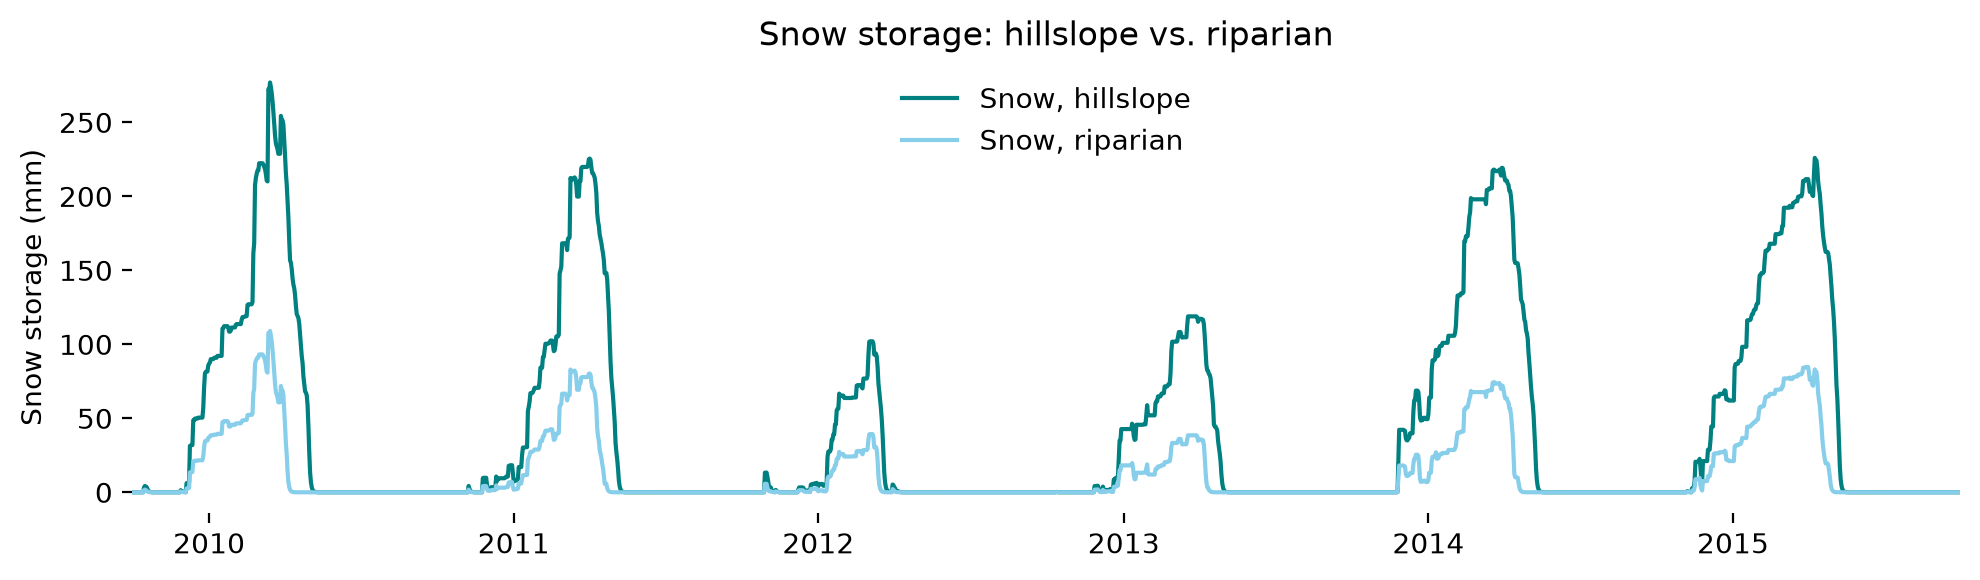

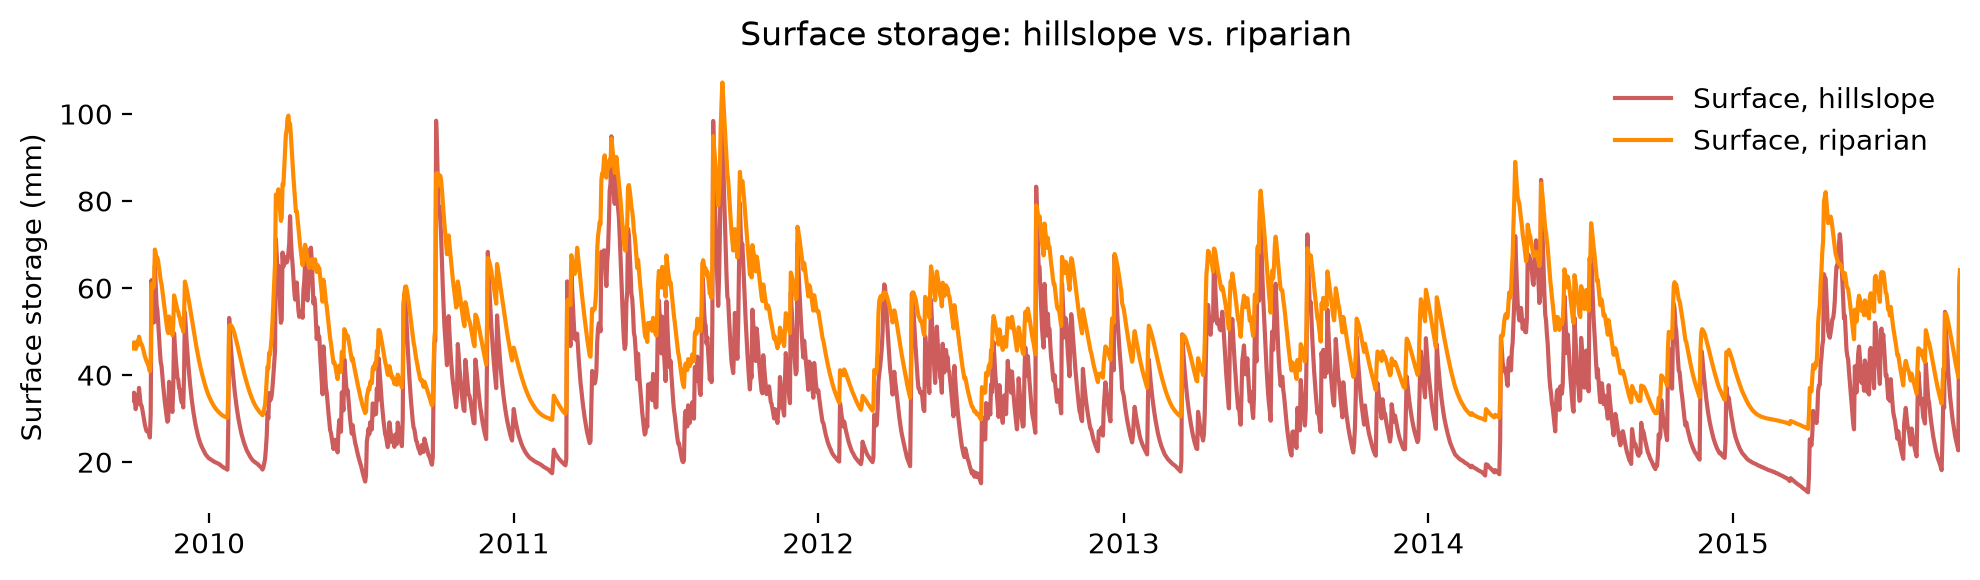

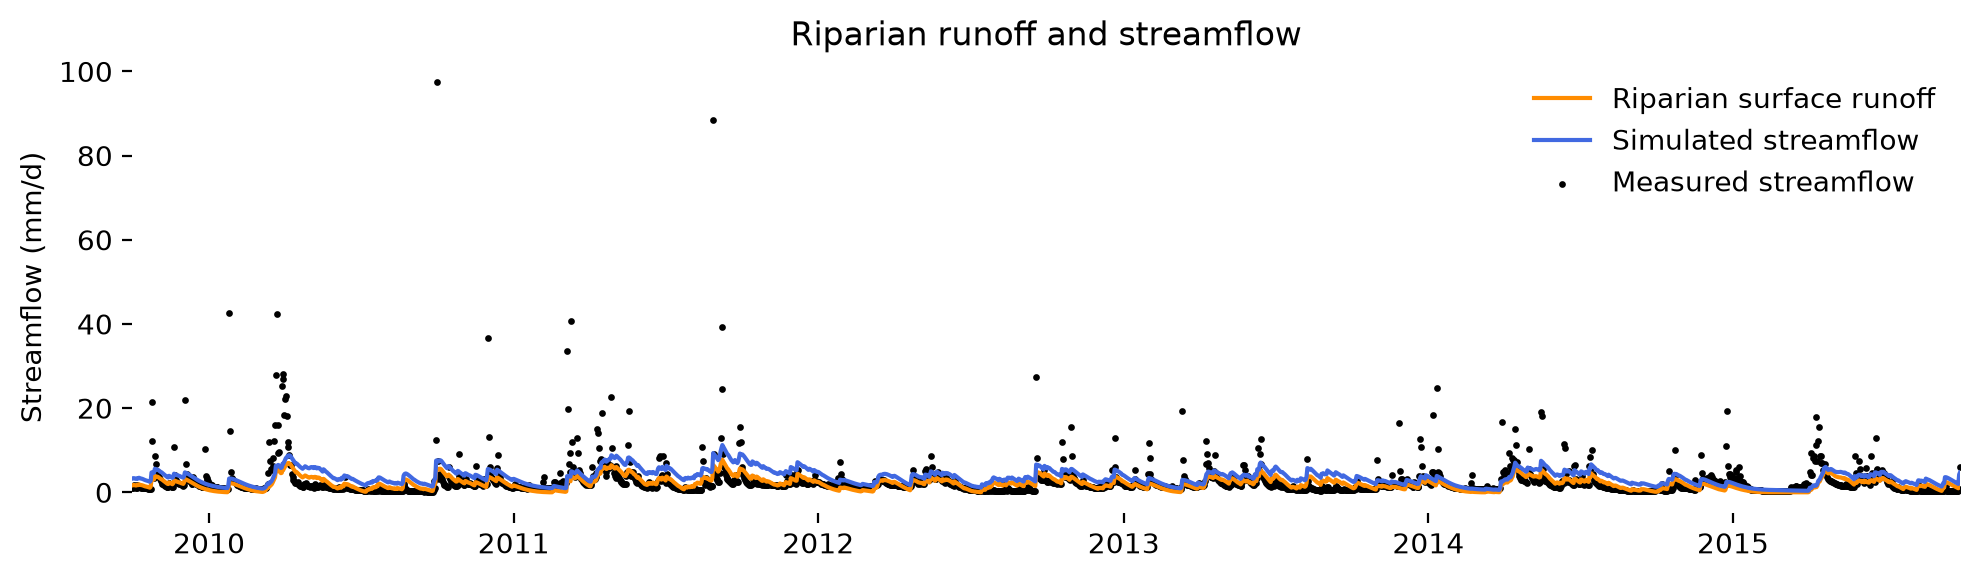

In [8]:
plt.rcParams["figure.dpi"] = 200
plt.rcParams["legend.frameon"] = False
plt.rcParams["axes.spines.bottom"] = False
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.left"] = False
plt.rcParams["axes.spines.right"] = False

obs_start: pd.Timestamp = meas_streamflow.index[0]
obs_end: pd.Timestamp = meas_streamflow.index[-1]

# ---- Panel A: snow storage, hillslope vs. riparian ---- #
fig_a: Figure = plt.figure(figsize=(10, 3))
ax_a: Axes = fig_a.gca()
ax_a.plot(
    simulation_df.index,
    simulation_df["s_snow_hs"],
    color="teal",
    label="Snow, hillslope",
)
ax_a.plot(
    simulation_df.index,
    simulation_df["s_snow_rp"],
    color="skyblue",
    label="Snow, riparian",
)
ax_a.set_xlim(obs_start, obs_end)
ax_a.set_ylabel("Snow storage (mm)")
ax_a.set_title("Snow storage: hillslope vs. riparian")
ax_a.legend()
fig_a.tight_layout()
plt.show()

# ---- Panel B: surface storage, hillslope vs. riparian ---- #
fig_b: Figure = plt.figure(figsize=(10, 3))
ax_b: Axes = fig_b.gca()
ax_b.plot(
    simulation_df.index,
    simulation_df["s_surface_hs"],
    color="indianred",
    label="Surface, hillslope",
)
ax_b.plot(
    simulation_df.index,
    simulation_df["s_surface_rp"],
    color="darkorange",
    label="Surface, riparian",
)
ax_b.set_xlim(obs_start, obs_end)
ax_b.set_ylabel("Surface storage (mm)")
ax_b.set_title("Surface storage: hillslope vs. riparian")
ax_b.legend()
fig_b.tight_layout()
plt.show()

# ---- Panel C: lateral (outlet) flux from the riparian zone + shared streamflow ---- #
fig_c: Figure = plt.figure(figsize=(10, 3))
ax_c: Axes = fig_c.gca()
ax_c.plot(
    simulation_df.index,
    simulation_df["q_lat_surface_rp"],
    color="darkorange",
    label="Riparian surface runoff",
)
ax_c.plot(
    simulation_df.index,
    simulation_df["streamflow_sim"],
    color="royalblue",
    label="Simulated streamflow",
)
ax_c.scatter(
    meas_streamflow.index,
    meas_streamflow,
    s=2,
    color="black",
    label="Measured streamflow",
)
ax_c.set_xlim(obs_start, obs_end)
ax_c.set_ylabel("Streamflow (mm/d)")
ax_c.set_title("Riparian runoff and streamflow")
ax_c.legend()
fig_c.tight_layout()
plt.show()